[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HSF-reco-and-software-triggers/Tracking-ML-Exa.TrkX/blob/master/Examples/TrackML_Quickstart/DM_colab_quickstart.ipynb)

# TrackML Quickstart

## Install Libraries

**Note: Before running notebook, ensure your runtime is set to GPU**

First, we just install a few libraries (this should take around 5 minutes and automatically restart the kernel), and load in the repository.

In [1]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

In [2]:
# !pip install seaborn bokeh 
# !conda install pandas scipy matplotlib cupy "cudatoolkit>=11.3" "pytorch>=1.10.2" "pytorch-lightning>=1.6" pyg faiss-gpu -c pytorch -c pyg -c conda-forge

In [3]:
# !git clone https://github.com/HSF-reco-and-software-triggers/Tracking-ML-Exa.TrkX.git
# %cd Tracking-ML-Exa.TrkX/Examples/TrackML_Quickstart

# Import libraries

In [4]:
import sys, os
sys.path.append("../../")
from Scripts import train_metric_learning, run_metric_learning_inference, train_gnn, run_gnn_inference, build_track_candidates, evaluate_candidates
from Scripts.utils.convenience_utils import get_example_data, plot_true_graph, get_training_metrics, plot_training_metrics, plot_neighbor_performance, plot_predicted_graph, plot_track_lengths, plot_edge_performance, plot_graph_sizes
import yaml

import warnings
warnings.filterwarnings("ignore")
CONFIG = 'pipeline_config_quirk.yaml'
# pipeline_config_quirk.yaml

Loading BokehJS ...

/home/rafia/miniconda3/envs/trackml-quickstart/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/home/rafia/miniconda3/envs/trackml-quickstart/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading BokehJS ...

## Download Data

In [5]:
# %%capture
# !mkdir datasets
# !wget https://portal.nersc.gov/cfs/m3443/dtmurnane/TrackML_Example/trackml_quickstart_dataset.tar.gz -O datasets/trackml_quickstart_dataset.tar.gz

In [6]:
# %%capture
# !tar -xvf datasets/trackml_quickstart_dataset.tar.gz -C datasets;
# !rm datasets/trackml_quickstart_dataset.tar.gz

## TrackML Dataset

The TrackML dataset contains simulated indepedent proton-proton collision events, each generating hundreds of particles, each of which hits cells and layers of the detector layers multiple times. The detector records the spatial coordinates and other auxillary information of these hits which, if properly connected, form tracks associated with the parent particle and the collision event from which it originates. The challenge and goal of this project is to associate each and every hit to one single track with optimal purity and efficiency, whose precise definition will be given later.

Each entry in the particles data frame contains a unique identifier of the particle (particle_id), its charge (q), its initial position or vertex $(v_x, v_y, v_z)$, its initial momentum in GeV/c $(p_x, p_y, p_z)$ and its associated number of detector hits. 

Many particles do not leave behind any detector hits and obviously cannot be associated to any track. This is called "detector inefficiency". They are among "uninterested particles" and will be mostly filtered out by a simple momentum cut.

### Training data
Let us take a look at the data before training. In this example pipeline, we have preprocessed the TrackML data into a more convenient form. We calculated directional information and summary statistics from the charge deposited in each spacepoints, and append them to its cyclidrical coordinates. Let us load an example data file and inspect the content.

In [7]:
with open(CONFIG, 'r') as f:
    configs = yaml.load(f, Loader=yaml.FullLoader)

In [8]:
example_data_df, example_data_pyg = get_example_data(configs)
example_data_df.head()

,0,1,2
0,0.032,-0.513864,0.004621
1,0.072,-0.542312,0.011868
2,0.116,-0.564147,0.020289
3,0.172,-0.591790,0.031683
4,0.260,-0.639711,0.050775


### Visualize tracks

A "true track" is defined as a set of sequential hits, all left by the same particle. Therefore a true edge is the edge formed by two sequential hits. Let's visualize a random set of 200 true tracks:

In [9]:
plot_true_graph_fig = plot_true_graph(example_data_pyg, num_tracks=200)

## Plot training metrics

We can examine how the training went. This is stored in a simple dataframe:

In [10]:
metric_learning_trainer, metric_learning_model = train_metric_learning(CONFIG)

INFO:-------------------- Step 1: Running metric learning training --------------------
INFO:----------------------------- a) Initialising model -----------------------------
INFO:------------------------------ b) Running training ------------------------------
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params
---------------------------------------
0 | network | Sequential | 3.2 M 
---------------------------------------
3.2 M     Trainable params
0   

Epoch 49: 100%|██████████| 450/450 [00:55<00:00,  8.11it/s, loss=0.00614, v_num=4]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 450/450 [00:55<00:00,  8.10it/s, loss=0.00614, v_num=4]


INFO:-------------------------------- c) Saving model --------------------------------


In [11]:
embedding_metrics = get_training_metrics(metric_learning_trainer)
embedding_metrics.head()

,epoch,train_loss,val_loss,eff,pur,current_lr
0,0,0.007452,0.005054,0.887799,0.215249,0.000125
1,1,0.007306,0.004662,0.885736,0.236239,0.000250
2,2,0.007222,0.004427,0.868843,0.270935,0.000375
3,3,0.007169,0.004471,0.880048,0.269979,0.000500
4,4,0.007118,0.004413,0.883406,0.290822,0.000625


In [12]:
embedding_training_figs = plot_training_metrics(embedding_metrics)

## Evaluate model performance on sample test data

Here we evaluate the model performace on one sample test data. We look at how the efficiency and purity change with the embedding radius.

In [13]:
neighbor_perf_figs = plot_neighbor_performance(metric_learning_model)

## Plot example truth and predicted graphs

In [14]:
predicted_graph_figs = plot_predicted_graph(metric_learning_model)

## Track lengths

In [15]:
track_length_figs = plot_track_lengths(metric_learning_model)

In [16]:
graph_sizes_fig = plot_graph_sizes(metric_learning_model)

100%|██████████| 400/400 [00:43<00:00,  9.16it/s]


# 2. Construct graphs from metric learning inference

This step performs model inference on the entire input datasets (train, validation and test), to obtain input graphs to the graph neural network. Optionally, we also clear the directory.

In [17]:
graph_builder = run_metric_learning_inference(CONFIG)

INFO:------------- Step 2: Constructing graphs from metric learning model -------------
INFO:---------------------------- a) Loading trained model ----------------------------
INFO:----------------------------- b) Running inferencing -----------------------------


Training finished, running inference to build graphs...


100%|██████████| 50/50 [00:05<00:00,  8.74it/s]


In [18]:
import os, gc, torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"Cleared CUDA cache on {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

print("Run this cell right before Step 3. If allocator behavior is unchanged, restart kernel once.")


Cleared CUDA cache on NVIDIA GeForce RTX 4090
Run this cell right before Step 3. If allocator behavior is unchanged, restart kernel once.


# 3. Train graph neural networks

We have a set of graphs constructed. We now train a GNN to classify edges as either "true" (belonging to the same track) or "false" (not belonging to the same track).

In [19]:
gnn_trainer, gnn_model = train_gnn(CONFIG)

INFO:-------------------------  Step 3: Running GNN training  -------------------------


INFO:----------------------------- a) Initialising model -----------------------------
INFO:------------------------------ b) Running training ------------------------------
Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                   | Type       | Params
------------------------------------------------------
0 | node_encoder           | Sequential | 9.9 K 
1 | edge_encoder           | Sequential | 28.0 K
2 | edge_network           | Sequential | 37.2 K
3 | node_network           | Sequential | 37.2 K
4 | output_edge_classifier | Sequential | 37.5 K
------------------------------------------------------
149 K     Trainable params
0         Non-trainable params
149 K     Total params
0.300     Total estimated model params size (MB)


Epoch 29: 100%|██████████| 450/450 [00:10<00:00, 41.88it/s, loss=0.00907, v_num=3]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 450/450 [00:10<00:00, 41.80it/s, loss=0.00907, v_num=3]


INFO:-------------------------------- c) Saving model --------------------------------


## Plot training metrics

In [20]:
gnn_metrics = get_training_metrics(gnn_trainer)
gnn_metrics.head()

,epoch,train_loss,val_loss,eff,pur,current_lr
0,0,0.156290,0.168496,0.943837,0.980370,0.0002
1,1,0.122864,0.139419,0.954220,0.987132,0.0004
2,2,0.092656,0.095437,0.967010,0.989326,0.0006
3,3,0.079132,0.080774,0.985230,0.987984,0.0008
4,4,0.063796,0.071383,0.980713,0.990613,0.0010


In [21]:
gnn_training_figs = plot_training_metrics(gnn_metrics)

## Evaluate model performance on sample test data

Here we evaluate the model performace on one sample test data. We look at how the efficiency and purity change with the embedding radius.

In [22]:
edge_perf_figs = plot_edge_performance(gnn_model)

# Step 4: GNN inference 

In [38]:
run_gnn_inference(CONFIG)

INFO:--------------------- Step 4: Scoring graph edges using GNN  ---------------------
INFO:---------------------------- a) Loading trained model ----------------------------
INFO:----------------------------- b) Running inferencing -----------------------------


Training finished, running inference to filter graphs...
Building train


100%|██████████| 400/400 [00:01<00:00, 220.23it/s]


Building val


100%|██████████| 50/50 [00:00<00:00, 220.79it/s]


Building test


100%|██████████| 50/50 [00:00<00:00, 221.92it/s]


In [42]:
# ============================================================
# Average GNN edge filtering numbers over all test graphs
# ============================================================

import torch
import numpy as np
from pathlib import Path

gnn_dir = Path("datasets/quickstart_gnn_processed")

files = sorted((gnn_dir / "test").glob("*"))
if not files:
    files = sorted((gnn_dir / "testset").glob("*"))

edge_cut = 0.75

TP_total = 0
FP_total = 0
FN_total = 0
TN_total = 0

for f in files:
    data = torch.load(f, map_location="cpu", weights_only=False)

    scores = data.scores.detach().cpu().numpy()
    truth = data.y.detach().cpu().bool().numpy()

    kept = scores >= edge_cut

    TP_total += int((kept & truth).sum())
    FP_total += int((kept & ~truth).sum())
    FN_total += int((~kept & truth).sum())
    TN_total += int((~kept & ~truth).sum())

true_edges = TP_total + FN_total
wrong_edges = FP_total + TN_total
total_edges = true_edges + wrong_edges

efficiency = TP_total / true_edges if true_edges > 0 else 0
purity = TP_total / (TP_total + FP_total) if (TP_total + FP_total) > 0 else 0
wrong_rejection = TN_total / wrong_edges if wrong_edges > 0 else 0
fake_kept_rate = FP_total / wrong_edges if wrong_edges > 0 else 0

print("\n===== GNN Edge Filtering on Full Test Set =====")
print("Number of test graphs:", len(files))
print("Score cut:", edge_cut)

print("\nCounts:")
print("Total candidate edges:", total_edges)
print("True edges:", true_edges)
print("Wrong edges:", wrong_edges)

print("\nConfusion matrix:")
print("TP kept true edges:      ", TP_total)
print("FP kept wrong edges:     ", FP_total)
print("FN removed true edges:   ", FN_total)
print("TN removed wrong edges:  ", TN_total)

print("\nMetrics:")
print(f"Edge efficiency:        {efficiency:.3f} = {efficiency*100:.1f}%")
print(f"Edge purity:            {purity:.3f} = {purity*100:.1f}%")
print(f"Wrong-edge rejection:   {wrong_rejection:.3f} = {wrong_rejection*100:.1f}%")
print(f"Fake kept rate:         {fake_kept_rate:.3f} = {fake_kept_rate*100:.1f}%")


===== GNN Edge Filtering on Full Test Set =====
Number of test graphs: 50
Score cut: 0.75

Counts:
Total candidate edges: 9202
True edges: 1365
Wrong edges: 7837

Confusion matrix:
TP kept true edges:       1320
FP kept wrong edges:      5836
FN removed true edges:    45
TN removed wrong edges:   2001

Metrics:
Edge efficiency:        0.967 = 96.7%
Edge purity:            0.184 = 18.4%
Wrong-edge rejection:   0.255 = 25.5%
Fake kept rate:         0.745 = 74.5%


In [43]:
# ============================================================
# Per-event GNN filtering numbers for all test graphs
# ============================================================

import torch
import pandas as pd
from pathlib import Path

gnn_dir = Path("datasets/quickstart_gnn_processed")

files = sorted((gnn_dir / "test").glob("*"))
if not files:
    files = sorted((gnn_dir / "testset").glob("*"))

edge_cut = 0.75
rows = []

for f in files:
    data = torch.load(f, map_location="cpu", weights_only=False)

    scores = data.scores.detach().cpu().numpy()
    truth = data.y.detach().cpu().bool().numpy()
    kept = scores >= edge_cut

    TP = int((kept & truth).sum())
    FP = int((kept & ~truth).sum())
    FN = int((~kept & truth).sum())
    TN = int((~kept & ~truth).sum())

    eff = TP / (TP + FN) if (TP + FN) > 0 else 0
    pur = TP / (TP + FP) if (TP + FP) > 0 else 0

    rows.append({
        "event": f.name,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "efficiency_%": round(eff * 100, 1),
        "purity_%": round(pur * 100, 1),
    })

df = pd.DataFrame(rows)
display(df)

print("\nAverage:")
print(df[["TP", "FP", "FN", "TN", "efficiency_%", "purity_%"]].mean())

,event,TP,FP,FN,TN,efficiency_%,purity_%
0,0013,24,140,0,40,100.0,14.6
1,0019,18,149,0,40,100.0,10.8
2,0021,23,113,3,35,88.5,16.9
3,0022,23,138,3,39,88.5,14.3
4,0035,27,120,0,40,100.0,18.4
5,0044,44,92,1,44,97.8,32.4
6,0061,47,95,1,43,97.9,33.1
7,0100,22,114,5,33,81.5,16.2
8,0113,24,140,0,40,100.0,14.6
9,0121,20,112,6,37,76.9,15.2



Average:
TP               26.400
FP              116.720
FN                0.900
TN               40.020
efficiency_%     96.668
purity_%         18.806
dtype: float64


Using GNN files from: /home/rafia/trackml-quickstart-collab/Examples/TrackML_Quickstart/datasets/quickstart_gnn_processed/test


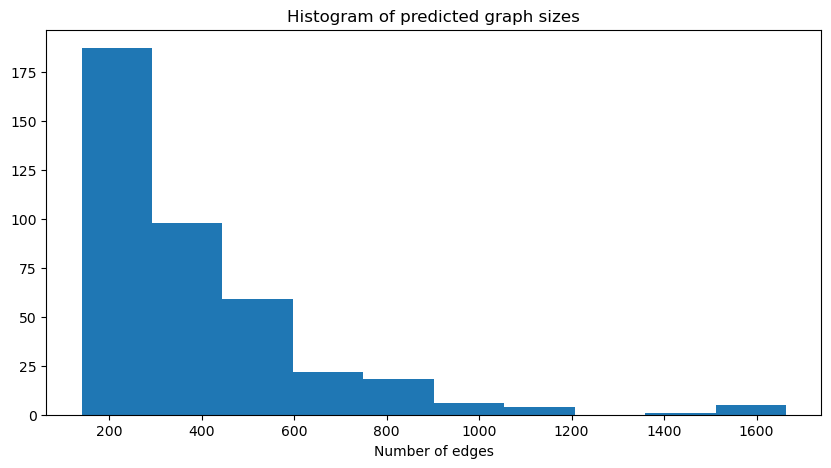

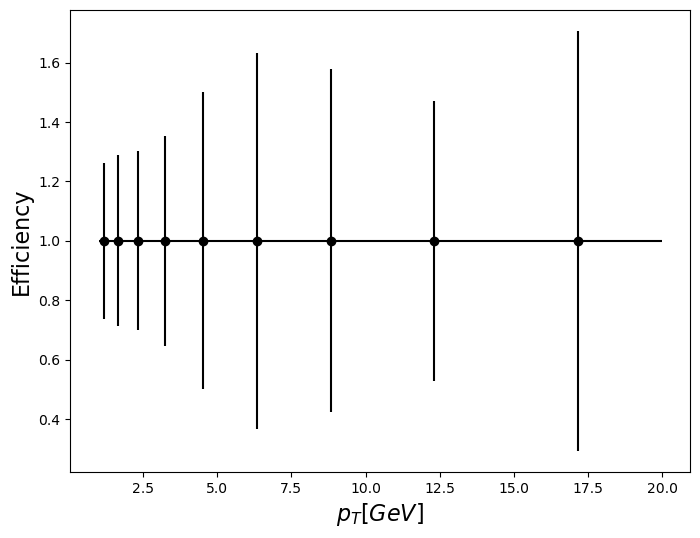

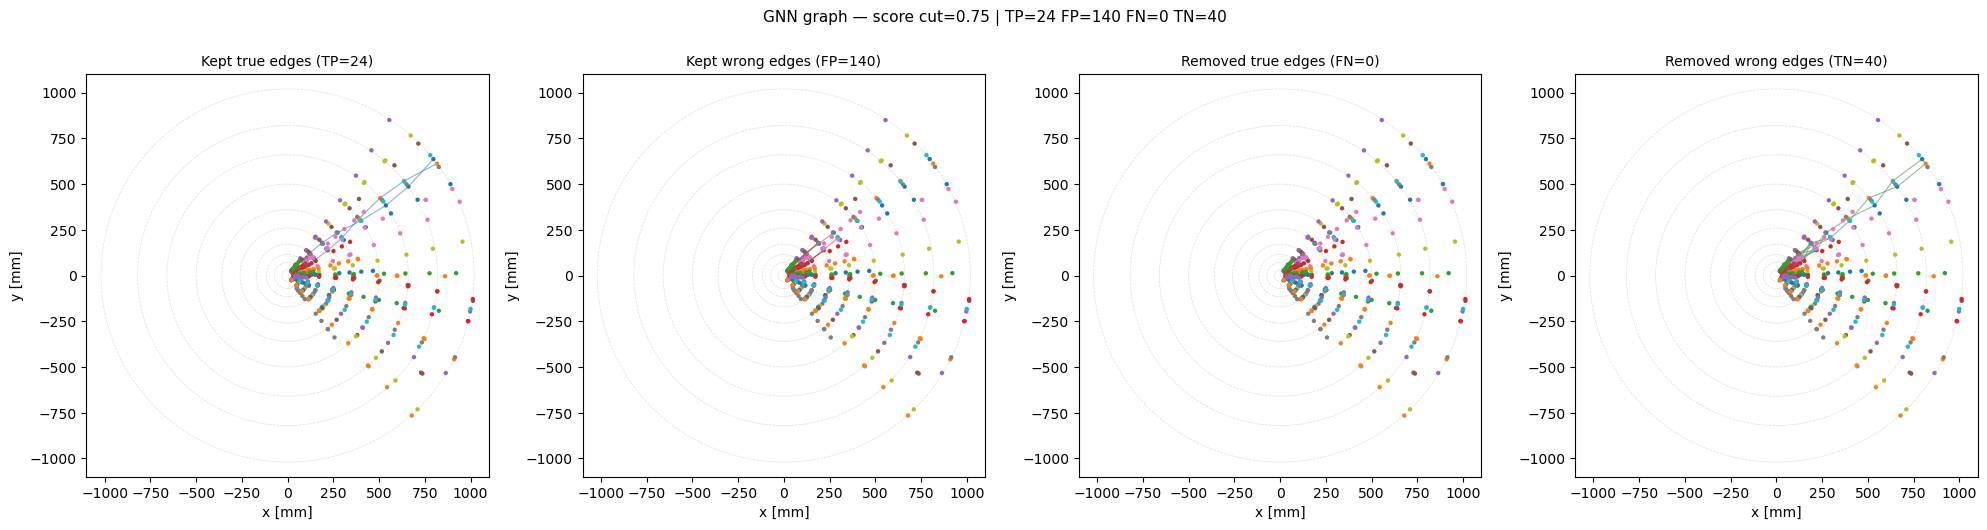

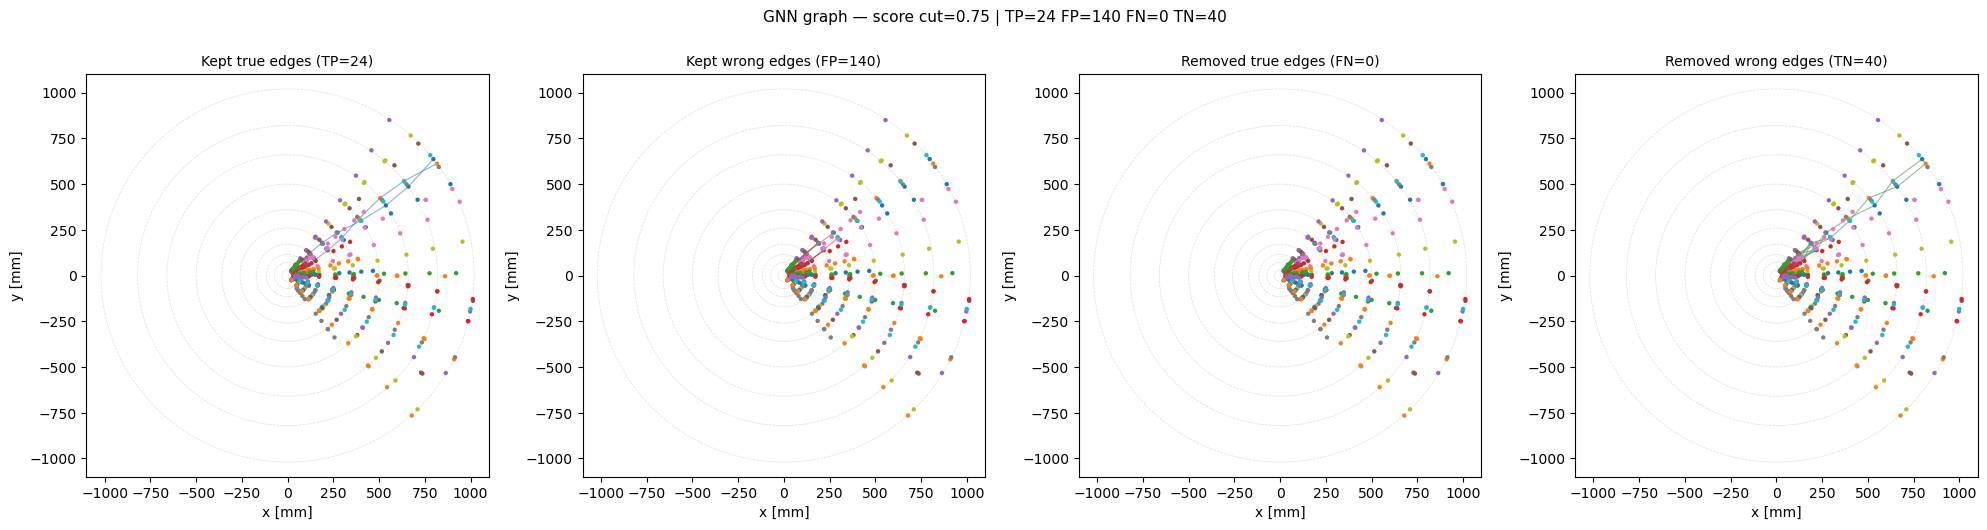

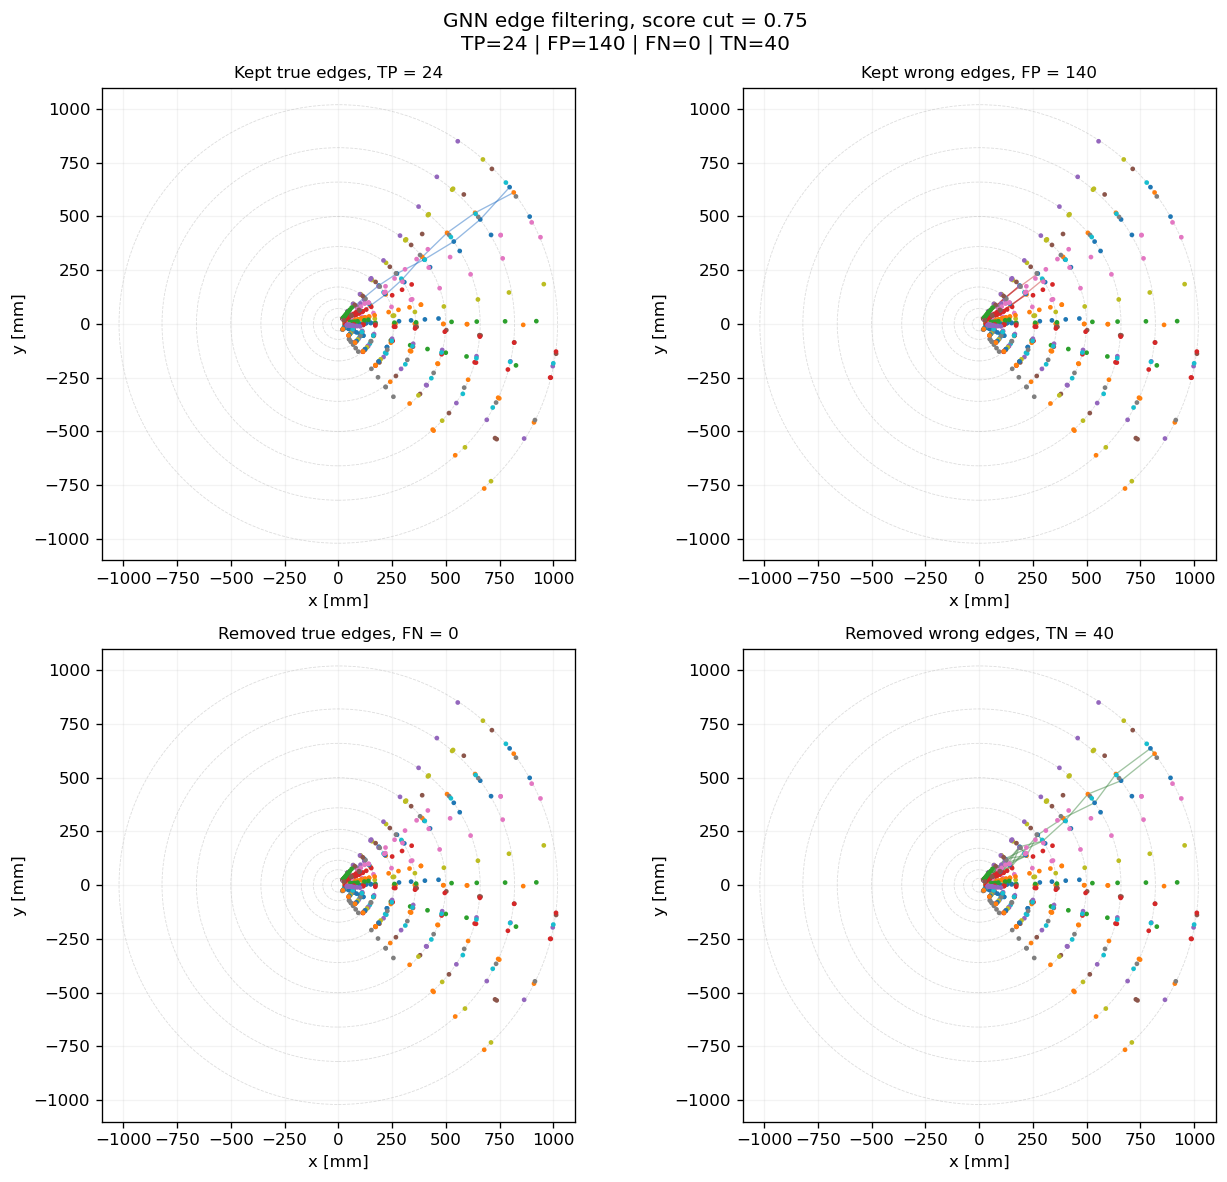

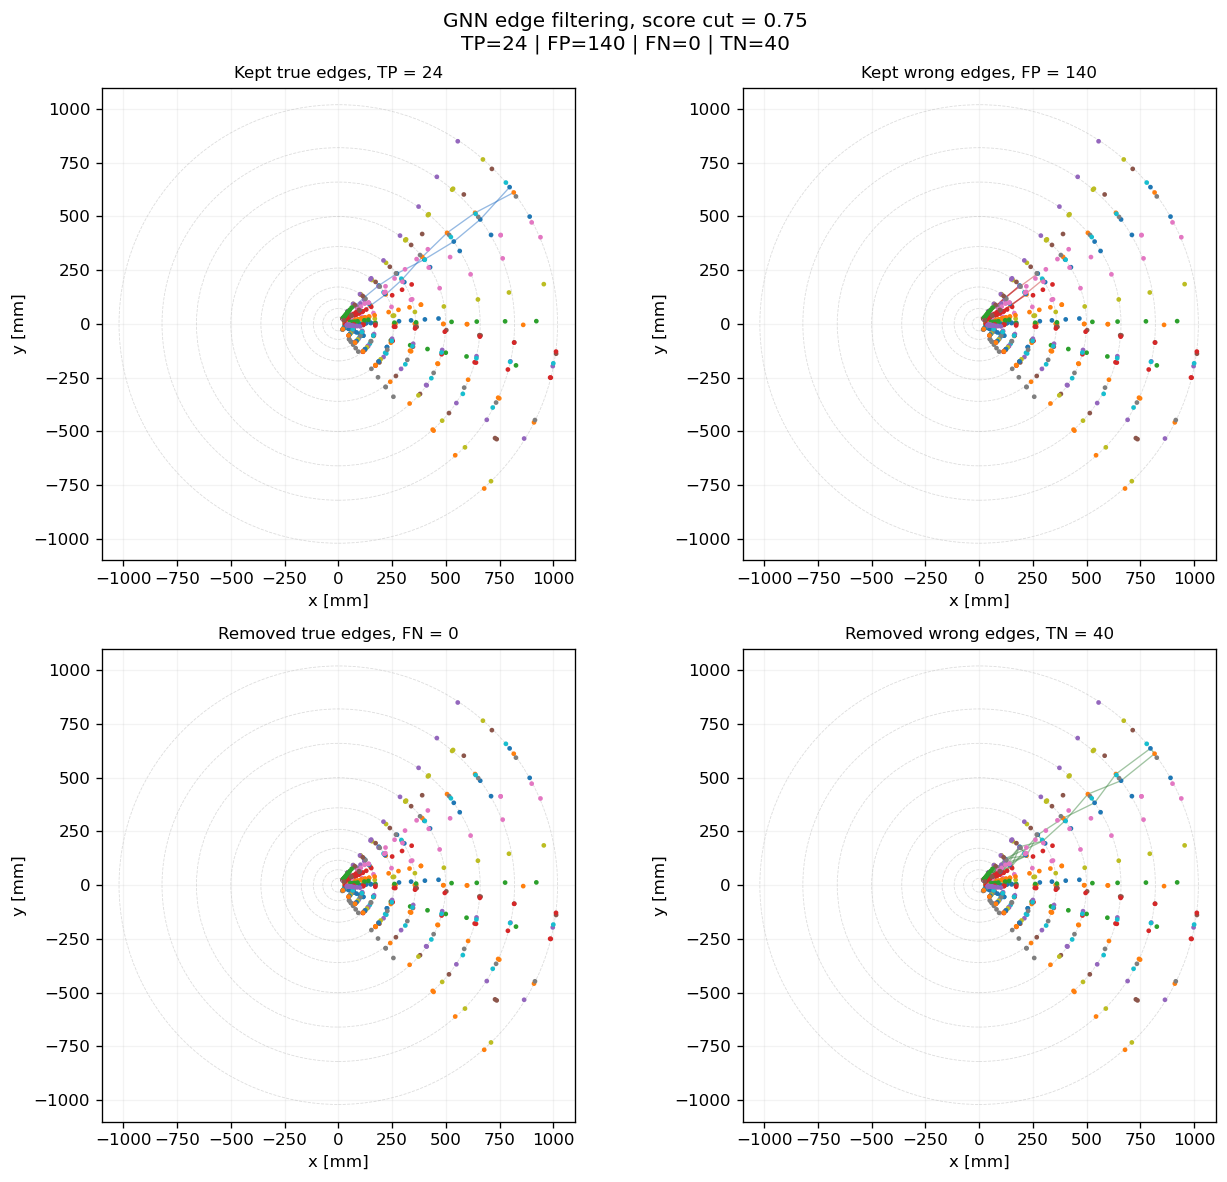

Plotted file: /home/rafia/trackml-quickstart-collab/Examples/TrackML_Quickstart/datasets/quickstart_gnn_processed/test/0013


In [40]:
%matplotlib inline

import importlib
import matplotlib.pyplot as plt
from IPython.display import display
import Pipelines.TrackML_Example.notebooks.plot_gnn as plot_gnn

importlib.reload(plot_gnn)

fig = plot_gnn.plot_gnn_event(
    "datasets/quickstart_gnn_processed",
    score_cut=0.75,
    max_edges=300,
    save=False
)

plt.show()

# Step 5: Build track candidates from GNN

In [24]:
build_track_candidates(CONFIG)

INFO:-----------  Step 5: Building track candidates from the scored graph  -----------
INFO:---------------------------- a) Loading scored graphs ----------------------------
INFO:---------------------------- b) Labelling graph nodes ----------------------------
100%|██████████| 500/500 [00:00<00:00, 987.16it/s]


# Step 6: Evaluate track candidates

We can control the matching style in the pipeline config file. The following all require at least a majority of hits to match in each scheme (i.e. matching fraction = 50%).
A discussion of each matching style and some worked examples can be found in the [Documentation](https://hsf-reco-and-software-triggers.github.io/Tracking-ML-Exa.TrkX/performance/matching_definitions/).

ATLAS style matching is the default.

In [25]:
evaluated_events, reconstructed_particles, particles, matched_tracks, tracks = evaluate_candidates(CONFIG)

INFO:------------ Step 6: Evaluating the track reconstruction performance ------------
INFO:--------------------------- a) Loading labelled graphs ---------------------------
100%|██████████| 500/500 [00:04<00:00, 117.50it/s]
INFO:--------------------- b) Calculating the performance metrics ---------------------
INFO:Number of reconstructed particles: 995
INFO:Number of particles: 21690
INFO:Number of matched tracks: 995
INFO:Number of tracks: 997
INFO:Number of duplicate reconstructed particles: 0
INFO:Efficiency: 0.046
INFO:Fake rate: 0.002
INFO:Duplication rate: 0.000
INFO:------------------------------ c) Plotting results ------------------------------


In [26]:
# Optional: save selected plots from this notebook
import os
from pathlib import Path

import matplotlib.pyplot as plt
from bokeh.io import export_png

SAVE_PLOTS = True  # Set True when you want to export
OUTPUT_DIR = Path("saved_plots")
MATPLOTLIB_DPI = 500
BOKEH_SCALE_FACTOR = 5

# Choose what to save
TO_SAVE = [
    "plot_true_graph",
    "embedding_training",
    "neighbor_performance",
    "predicted_graph",
    "track_lengths",
    "graph_sizes",
    "gnn_training",
    "edge_performance",
]

plot_registry = {
    "plot_true_graph": locals().get("plot_true_graph_fig"),
    "embedding_training": locals().get("embedding_training_figs"),
    "neighbor_performance": locals().get("neighbor_perf_figs"),
    "predicted_graph": locals().get("predicted_graph_figs"),
    "track_lengths": locals().get("track_length_figs"),
    "graph_sizes": locals().get("graph_sizes_fig"),
    "gnn_training": locals().get("gnn_training_figs"),
    "edge_performance": locals().get("edge_perf_figs"),
}

def _bokeh_figures(obj):
    if obj is None:
        return []
    if isinstance(obj, dict) and "figures" in obj:
        return obj["figures"]
    return [obj]

def _save_matplotlib(fig, outpath):
    fig.savefig(outpath, dpi=MATPLOTLIB_DPI, bbox_inches="tight")

def _save_bokeh(fig, outpath):
    # Requires selenium + browser driver for PNG export.
    export_png(fig, filename=str(outpath), scale_factor=BOKEH_SCALE_FACTOR)

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved, skipped, failed = [], [], []

    for name in TO_SAVE:
        obj = plot_registry.get(name)
        if obj is None:
            skipped.append((name, "plot object not found (run the source plotting cell first)"))
            continue

        if name == "graph_sizes":
            try:
                out = OUTPUT_DIR / f"{name}.png"
                _save_matplotlib(obj, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((name, str(exc)))
            continue

        figs = _bokeh_figures(obj)
        for idx, fig in enumerate(figs, start=1):
            suffix = f"_{idx}" if len(figs) > 1 else ""
            out = OUTPUT_DIR / f"{name}{suffix}.png"
            try:
                _save_bokeh(fig, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((f"{name}{suffix}", str(exc)))

    print(f"Saved {len(saved)} plot files")
    if saved:
        print("\n".join(saved))
    if skipped:
        print("\nSkipped:")
        for n, msg in skipped:
            print(f"- {n}: {msg}")
    if failed:
        print("\nFailed:")
        for n, msg in failed:
            print(f"- {n}: {msg}")
else:
    print("Set SAVE_PLOTS = True and rerun this cell to export selected plots.")

Saved 1 plot files
saved_plots/graph_sizes.png

Failed:
- plot_true_graph: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- embedding_training_1: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- embedding_training_2: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- embedding_training_3: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- neighbor_performance_1: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- neighbor_performance_2: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- neighbor_performance_3: To use bokeh.io image export functions you need selenium ('conda install selenium' or 'pip install selenium')
- pre

In [27]:
print(plot_true_graph_fig if "plot_true_graph_fig" in locals() else "missing")
print(embedding_training_figs if "embedding_training_figs" in locals() else "missing")


figure(id='p1008', ...)
{'layout': Row(id='p1377', ...), 'figures': [figure(id='p1190', ...), figure(id='p1267', ...), figure(id='p1322', ...)]}


In [28]:
# Save notebook plots: Bokeh as individual HTML files, Matplotlib as PNG
from pathlib import Path

from bokeh.io import output_file, save
import matplotlib.pyplot as plt

SAVE_PLOTS = True
OUTPUT_DIR = Path("saved_plots")
MATPLOTLIB_DPI = 600

TO_SAVE = [
    "plot_true_graph",
    "embedding_training",
    "neighbor_performance",
    "predicted_graph",
    "track_lengths",
    "graph_sizes",
    "gnn_training",
    "edge_performance",
]

plot_registry = {
    "plot_true_graph": locals().get("plot_true_graph_fig"),
    "embedding_training": locals().get("embedding_training_figs"),
    "neighbor_performance": locals().get("neighbor_perf_figs"),
    "predicted_graph": locals().get("predicted_graph_figs"),
    "track_lengths": locals().get("track_length_figs"),
    "graph_sizes": locals().get("graph_sizes_fig"),
    "gnn_training": locals().get("gnn_training_figs"),
    "edge_performance": locals().get("edge_perf_figs"),
}

def _bokeh_figures(obj):
    if obj is None:
        return []
    if isinstance(obj, dict) and "figures" in obj:
        return obj["figures"]
    return [obj]

def _save_matplotlib(fig, outpath):
    fig.savefig(outpath, dpi=MATPLOTLIB_DPI, bbox_inches="tight")

def _save_bokeh_html(fig, outpath):
    output_file(str(outpath), title=outpath.stem)
    save(fig)

if SAVE_PLOTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved, skipped, failed = [], [], []

    for name in TO_SAVE:
        obj = plot_registry.get(name)
        if obj is None:
            skipped.append((name, "plot object not found (run the source plotting cell first)"))
            continue

        if name == "graph_sizes":
            try:
                out = OUTPUT_DIR / f"{name}.png"
                _save_matplotlib(obj, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((name, str(exc)))
            continue

        figs = _bokeh_figures(obj)
        for idx, fig in enumerate(figs, start=1):
            suffix = f"_{idx}" if len(figs) > 1 else ""
            out = OUTPUT_DIR / f"{name}{suffix}.html"
            try:
                _save_bokeh_html(fig, out)
                saved.append(str(out))
            except Exception as exc:
                failed.append((f"{name}{suffix}", str(exc)))

    print(f"Saved {len(saved)} plot files")
    if saved:
        print("\n".join(saved))
    if skipped:
        print("\nSkipped:")
        for n, msg in skipped:
            print(f"- {n}: {msg}")
    if failed:
        print("\nFailed:")
        for n, msg in failed:
            print(f"- {n}: {msg}")
else:
    print("Set SAVE_PLOTS = True and rerun this cell to export selected plots.")


INFO:bokeh.io.state:Session output file 'saved_plots/plot_true_graph.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/embedding_training_1.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/embedding_training_2.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/embedding_training_3.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/neighbor_performance_1.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/neighbor_performance_2.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/neighbor_performance_3.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/predicted_graph_1.html' already exists, will be overwritten.
INFO:bokeh.io.state:Session output file 'saved_plots/predicted_gra

Saved 17 plot files
saved_plots/plot_true_graph.html
saved_plots/embedding_training_1.html
saved_plots/embedding_training_2.html
saved_plots/embedding_training_3.html
saved_plots/neighbor_performance_1.html
saved_plots/neighbor_performance_2.html
saved_plots/neighbor_performance_3.html
saved_plots/predicted_graph_1.html
saved_plots/predicted_graph_2.html
saved_plots/track_lengths_1.html
saved_plots/track_lengths_2.html
saved_plots/graph_sizes.png
saved_plots/gnn_training_1.html
saved_plots/gnn_training_2.html
saved_plots/gnn_training_3.html
saved_plots/edge_performance_1.html
saved_plots/edge_performance_2.html
